<a href="https://colab.research.google.com/github/kush450629/ME421_GROUP_A1/blob/main/Twin_rotor/ME421_E20021_Twin_Rotor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

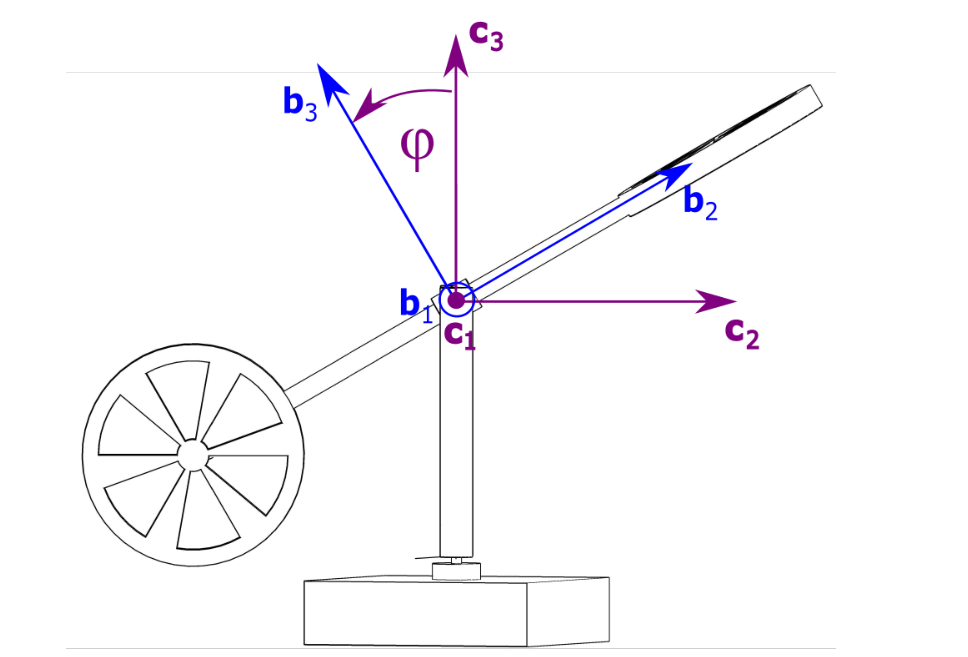

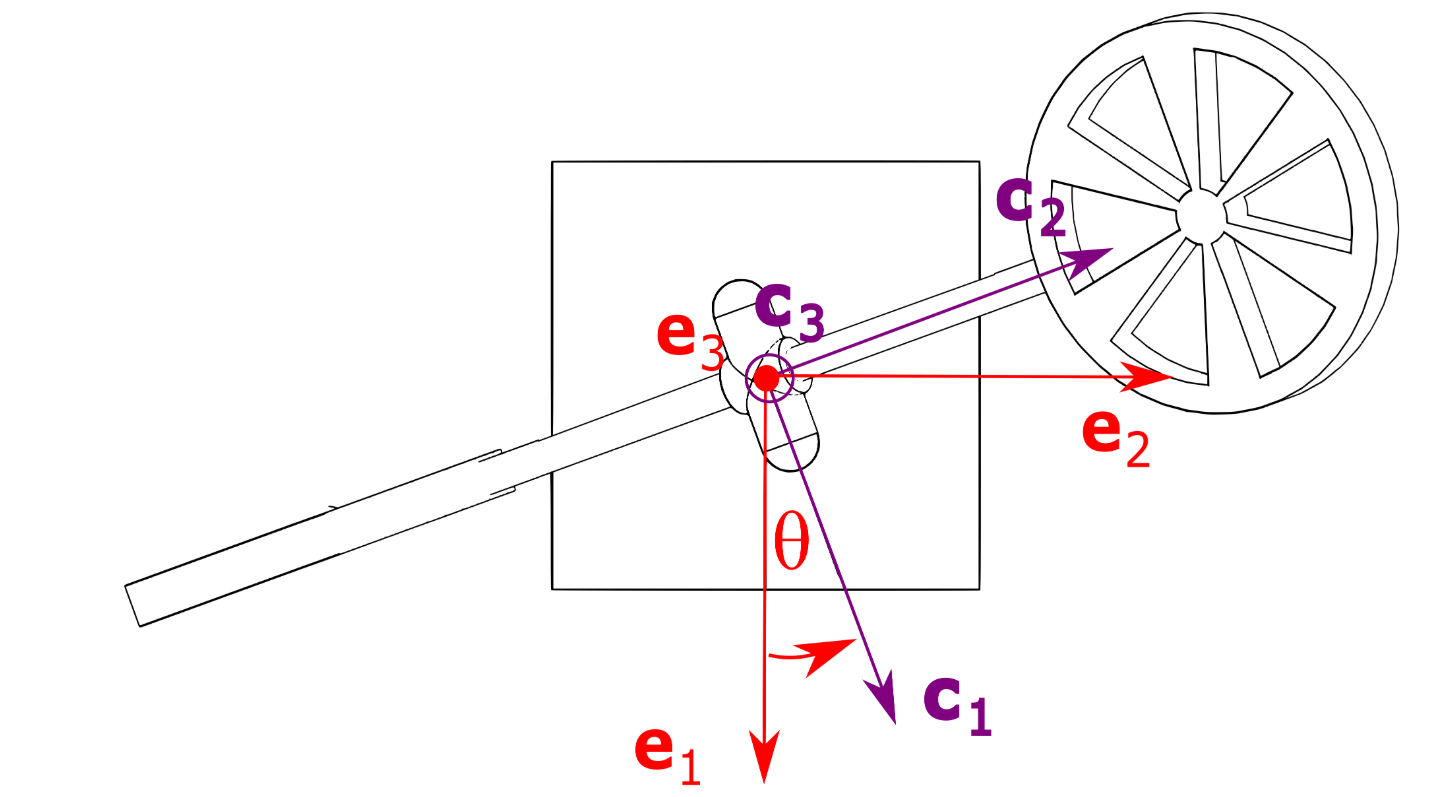

# Task #1: Twin Rotor System Dynamic **Model**

### Coordinate Transformations

Let the **Earth frame** be denoted as $e$ and another frame as $c$.  
The origins of both frames coincide, and their vertical axes ($e_3$ and $c_3$) also coincide.

The coordinate transformation from the Earth frame $e$ to frame $c$ is a **rotation about the vertical 3-axis** by an angle $\theta$. This is expressed as:

$$
\mathbf{c} = \mathbf{e} \, R_{3}(\theta)
$$

where the rotation matrix $R_{3}(\theta)$ is:

$$
R_{3}(\theta) = \begin{bmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta & \cos\theta & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

---

Next, we define the **body frame** $b$ relative to frame $c$.  
The origins of both frames coincide, and their 1-axes ($b_1$ and $c_1$) also coincide.  
**Note:** The axis $b_2$ runs along the length of the rotor arm.

The coordinate transformation from frame $c$ to the body frame $b$ is a **rotation about the 1-axis** by an angle $\phi$. This is expressed as:

$$
\mathbf{b} = \mathbf{c} \, R_{1}(\phi)
$$

where the fundamental rotation matrix for the 1-axis is:

$$
R_{1}(\phi) = \begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\phi & -\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}
$$

---

### Combined Rotation Matrix

Now, we can find the total coordinate transformation from the Earth frame $e$ directly to the body frame $b$ by combining the two transformations.

Given:
1. $\mathbf{c} = \mathbf{e} \, R_{3}(\theta)$
2. $\mathbf{b} = \mathbf{c} \, R_{1}(\phi)$

Substituting gives:

$$
\mathbf{b} = \mathbf{e} \, (R_{3}(\theta) \, R_{1}(\phi))
$$

Let the **combined rotation matrix** be $R = R_{3}(\theta) \, R_{1}(\phi)$.

Computing the matrix multiplication:

$$
R = \begin{bmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta & \cos\theta & 0 \\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\phi & -\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}
= \begin{bmatrix}
\cos\theta & -\sin\theta\cos\phi & \sin\theta\sin\phi \\
\sin\theta & \cos\theta\cos\phi & -\cos\theta\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}
$$

---

Therefore, the full coordinate transformation from the Earth frame to the body frame is:

$$
\mathbf{b} = \mathbf{e} \, R
$$

where

$$
R = \begin{bmatrix}
\cos\theta & -\sin\theta\cos\phi & \sin\theta\sin\phi \\
\sin\theta & \cos\theta\cos\phi & -\cos\theta\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}
$$

### Derivation of Angular Velocity

To find the angular velocity of the body frame $b$ relative to the Earth frame $e$, we start with the time derivative of the combined rotation matrix $R = R_{3}(\theta) R_{1}(\phi)$.

Using the product rule:

$$
\dot{R} = \dot{R}_{3}(\theta) \, R_{1}(\phi) + R_{3}(\theta) \, \dot{R}_{1}(\phi)
$$

In rigid body kinematics, the time derivative of the rotation matrix relates to the skew-symmetric angular velocity matrix $\hat{\Omega}$ (expressed in the body frame) via:

$$
\dot{R} = R \, \hat{\Omega}
$$

Solving for $\hat{\Omega}$ gives:

$$
\hat{\Omega} = R^T \dot{R}
$$

Substituting $R = R_{3}(\theta) R_{1}(\phi)$ yields $R^T = R_{1}(\phi)^T R_{3}(\theta)^T$. Therefore:

$$
\hat{\Omega} = R_{1}(\phi)^T R_{3}(\theta)^T \left( \dot{R}_{3}(\theta) R_{1}(\phi) + R_{3}(\theta) \dot{R}_{1}(\phi) \right)
$$

Expanding:

$$
\hat{\Omega} = R_{1}(\phi)^T \left( R_{3}(\theta)^T \dot{R}_{3}(\theta) \right) R_{1}(\phi) + R_{1}(\phi)^T \left( R_{3}(\theta)^T R_{3}(\theta) \right) \dot{R}_{1}(\phi)
$$

Since $R_{3}(\theta)$ is orthogonal, $R_{3}(\theta)^T R_{3}(\theta) = I$, so the equation simplifies to:

$$
\hat{\Omega} = R_{1}(\phi)^T \left( R_{3}(\theta)^T \dot{R}_{3}(\theta) \right) R_{1}(\phi) + R_{1}(\phi)^T \dot{R}_{1}(\phi)
$$

The terms $R_{3}(\theta)^T \dot{R}_{3}(\theta)$ and $R_{1}(\phi)^T \dot{R}_{1}(\phi)$ are skew-symmetric matrices corresponding to the angular rates about their respective axes:

**1. Rotation about the 3-axis** (frame $c$ relative to $e$, rate $\dot{\theta}$):

$$
R_{3}(\theta)^T \dot{R}_{3}(\theta) = \dot{\theta} \hat{c}_3 = \begin{bmatrix}
0 & -\dot{\theta} & 0 \\
\dot{\theta} & 0 & 0 \\
0 & 0 & 0
\end{bmatrix}
$$

**2. Rotation about the 1-axis** (frame $b$ relative to $c$, rate $\dot{\phi}$):

$$
R_{1}(\phi)^T \dot{R}_{1}(\phi) = \dot{\phi} \hat{c}_1 = \begin{bmatrix}
0 & 0 & 0 \\
0 & 0 & -\dot{\phi} \\
0 & \dot{\phi} & 0
\end{bmatrix}
$$

Now substitute back:

$$
\hat{\Omega} = R_{1}(\phi)^T \, (\dot{\theta} \hat{c}_3) \, R_{1}(\phi) + \dot{\phi} \hat{c}_1
$$

First, compute $R_{1}(\phi)^T (\dot{\theta} \hat{c}_3) R_{1}(\phi)$:

$$
R_{1}(\phi)^T (\dot{\theta} \hat{c}_3) R_{1}(\phi) = \begin{bmatrix}
0 & -\dot{\theta}\cos\phi & \dot{\theta}\sin\phi \\
\dot{\theta}\cos\phi & 0 & 0 \\
-\dot{\theta}\sin\phi & 0 & 0
\end{bmatrix}
$$

Adding the second term $\dot{\phi} \hat{c}_1$:

$$
\hat{\Omega} = \begin{bmatrix}
0 & -\dot{\theta}\cos\phi & \dot{\theta}\sin\phi \\
\dot{\theta}\cos\phi & 0 & -\dot{\phi} \\
-\dot{\theta}\sin\phi & \dot{\phi} & 0
\end{bmatrix}
$$

Finally, the angular velocity vector $\boldsymbol{\Omega}$ in the **body frame** $b$ is extracted from the skew-symmetric matrix $\hat{\Omega}$:

$$
\boldsymbol{\Omega} = \begin{bmatrix}
\dot{\phi} \\
\dot{\theta} \sin\phi \\
\dot{\theta} \cos\phi
\end{bmatrix}
$$

This represents the body-frame angular velocity components:  
- $\Omega_1 = \dot{\phi}$ (along $b_1$)  
- $\Omega_2 = \dot{\theta} \sin\phi$ (along $b_2$)  
- $\Omega_3 = \dot{\theta} \cos\phi$ (along $b_3$)

### Angular Momentum in the Earth Frame

To find the angular momentum in the Earth frame (denoted as $\boldsymbol{\pi}$), we first define the angular momentum in the body frame (denoted as $\boldsymbol{\Pi}$).

Assuming the body axes align with the principal axes of inertia of the twin-rotor system, the inertia tensor $\mathbb{I}$ in the body frame is diagonal:

$$
\mathbb{I} = \begin{bmatrix}
I_1 & 0 & 0 \\
0 & I_2 & 0 \\
0 & 0 & I_3
\end{bmatrix}
$$

The angular momentum in the body frame is then:

$$
\boldsymbol{\Pi} = \mathbb{I} \, \boldsymbol{\Omega} = \begin{bmatrix}
I_1 & 0 & 0 \\
0 & I_2 & 0 \\
0 & 0 & I_3
\end{bmatrix}
\begin{bmatrix}
\dot{\phi} \\
\dot{\theta}\sin\phi \\
\dot{\theta}\cos\phi
\end{bmatrix}
= \begin{bmatrix}
I_1 \dot{\phi} \\
I_2 \dot{\theta}\sin\phi \\
I_3 \dot{\theta}\cos\phi
\end{bmatrix}
$$

Since a vector in the body frame is transformed to the Earth frame by pre-multiplying with the rotation matrix $R$ (from the relation $\mathbf{b} = \mathbf{e} R$), the angular momentum in the Earth frame $\boldsymbol{\pi}$ is:

$$
\boldsymbol{\pi} = R \, \boldsymbol{\Pi}
$$

Substituting the expressions for $R$ and $\boldsymbol{\Pi}$:

$$
\boldsymbol{\pi} = \begin{bmatrix}
\cos\theta & -\sin\theta\cos\phi & \sin\theta\sin\phi \\
\sin\theta & \cos\theta\cos\phi & -\cos\theta\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}
\begin{bmatrix}
I_1 \dot{\phi} \\
I_2 \dot{\theta}\sin\phi \\
I_3 \dot{\theta}\cos\phi
\end{bmatrix}
$$

Performing the matrix multiplication gives the components of $\boldsymbol{\pi}$ in the Earth frame:

$$
\boldsymbol{\pi} = \begin{bmatrix}
I_1 \dot{\phi} \cos\theta - I_2 \dot{\theta} \sin\phi \sin\theta \cos\phi + I_3 \dot{\theta} \cos\phi \sin\theta \sin\phi \\
I_1 \dot{\phi} \sin\theta + I_2 \dot{\theta} \sin\phi \cos\theta \cos\phi - I_3 \dot{\theta} \cos\phi \cos\theta \sin\phi \\
I_2 \dot{\theta} \sin\phi \sin\phi + I_3 \dot{\theta} \cos\phi \cos\phi
\end{bmatrix}
$$

This can be simplified by grouping terms, especially in the third component:

$$
\boldsymbol{\pi} = \begin{bmatrix}
I_1 \dot{\phi} \cos\theta - (I_2 - I_3) \dot{\theta} \sin\theta \sin\phi \cos\phi \\
I_1 \dot{\phi} \sin\theta + (I_2 - I_3) \dot{\theta} \cos\theta \sin\phi \cos\phi \\
\dot{\theta} (I_2 \sin^2\phi + I_3 \cos^2\phi)
\end{bmatrix}
$$

**Note:** The third component represents the projection of angular momentum along the vertical Earth axis ($e_3$), which is conserved in the absence of external torques about that axis.

### Reactive Torque in the Earth Frame

The only external torque acting on the system is the reactive torque that holds the rotor arm from rolling. This torque acts strictly along the 2-axis in the body frame ($b_2$). Let the magnitude of this torque be $T_2$.

The mechanical constraint torque vector in the body frame, $\boldsymbol{\tau}_e$, is therefore:

$$
\boldsymbol{\tau}_e = \begin{bmatrix}
0 \\
T_2 \\
0
\end{bmatrix}
$$

To express this reactive torque in the Earth frame (denoted as $\boldsymbol{T}_e$), we transform it using the rotation matrix $R$:

$$
\boldsymbol{T}_e = R \, \boldsymbol{\tau}_e
$$

Substituting the combined rotation matrix $R$:

$$
\boldsymbol{T}_e = \begin{bmatrix}
\cos\theta & -\sin\theta\cos\phi & \sin\theta\sin\phi \\
\sin\theta & \cos\theta\cos\phi & -\cos\theta\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}
\begin{bmatrix}
0 \\
T_2 \\
0
\end{bmatrix}
$$

Since we are multiplying by the second column of $R$, the resulting reactive torque in the Earth frame simplifies to:

$$
\boldsymbol{T}_e = \begin{bmatrix}
-T_2 \sin\theta \cos\phi \\
T_2 \cos\theta \cos\phi \\
T_2 \sin\phi
\end{bmatrix}
$$

**Note:** This torque $\boldsymbol{T}_e$ represents the external torque acting on the system as seen from the inertial Earth frame. It will be used in the Euler equations or Newton-Euler formulation for the dynamics of the twin-rotor system.

### Control Torque in the Body Frame

The control torques are generated by the thrust from the air on the two rotor blades. Let the torque magnitudes from rotor 1 and rotor 2 be $u_1$ and $u_2$, respectively.

The normal of the rotation plane for rotor 1 makes an angle $\alpha$ with the $b_1$ axis, and the normal for rotor 2 makes an angle $\beta$ with the $b_1$ axis. Assuming the rotors act purely in the $b_1$-$b_3$ plane, we can project these torques onto the body axes using trigonometric decomposition.

The control torque vector in the body frame, denoted as $\tau_u$, can be expressed in matrix form as:

$$\tau_u = \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \cos\alpha & -\cos\beta \\ \sin\alpha & -\sin\beta \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$$

Expanding this matrix multiplication gives the explicit components of the control torque along the body axes:

$$\tau_b^u = \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} u_1\cos\alpha - u_2\cos\beta \\ u_1\sin\alpha - u_2\sin\beta \end{bmatrix} = \begin{bmatrix} u_1\cos\alpha - u_2\cos\beta \\ 0 \\ u_1\sin\alpha - u_2\sin\beta \end{bmatrix}$$

To use this in the full spatial equations of motion, this body-frame torque must be mapped to the Earth frame (denoted as $T_u$) by pre-multiplying by the coordinate transformation matrix $R$:

$$T_u = R \tau_u = R \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \cos\alpha & -\cos\beta \\ \sin\alpha & -\sin\beta \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$$

### Equations of Motion: Rate of Change of Angular Momentum

We start with the fundamental definition of the spatial angular momentum in the Earth frame:
$$\pi = R \Pi$$

Where $\Pi = \mathbb{I}\Omega$ is the angular momentum in the body frame. To find the rate of change of spatial angular momentum, we take the time derivative using the product rule:

$$\dot{\pi} = \frac{d}{dt}(R \Pi) = \dot{R}\Pi + R\dot{\Pi}$$

From our earlier kinematic derivations, we know that the time derivative of the rotation matrix is related to the spatial angular velocity by $\dot{R} = R\hat{\Omega}$. Substituting this into our equation gives:

$$\dot{\pi} = (R\hat{\Omega})\Pi + R\dot{\Pi}$$

We can factor out the rotation matrix $R$:

$$\dot{\pi} = R(\hat{\Omega}\Pi + \dot{\Pi})$$

Recognizing that multiplying a vector by a skew-symmetric matrix is equivalent to a cross product ($\hat{\Omega}\Pi = \Omega \times \Pi$), and substituting $\Pi = \mathbb{I}\Omega$ and $\dot{\Pi} = \mathbb{I}\dot{\Omega}$, we get the full expression for the rate of change of spatial angular momentum:

$$\dot{\pi} = R(\Omega \times \mathbb{I}\Omega + \mathbb{I}\dot{\Omega})$$



### Equating to External Torques (Newton-Euler)

According to Newton-Euler equations, the rate of change of angular momentum equals the sum of external torques acting on the system in the Earth frame.
$$\dot{\pi} = T_e + T_u$$

Substituting our derived expression for $\dot{\pi}$:
$$R(\Omega \times \mathbb{I}\Omega + \mathbb{I}\dot{\Omega}) = T_e + T_u$$

To make this equation practically solvable for simulation, it is highly advantageous to map it back into the body frame by pre-multiplying both sides by $R^T$. Since $R^T R = I$, $R^T T_e = \tau_e$, and $R^T T_u = \tau_u$, this yields the classic Euler's equations for a rigid body:

$$\Omega \times \mathbb{I}\Omega + \mathbb{I}\dot{\Omega} = \tau_e + \tau_u$$

Since we previously defined our body-frame torques as:
$$\tau_e = \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix} \quad \text{and} \quad \tau_u = \begin{bmatrix} \tau_{u1} \\ 0 \\ \tau_{u3} \end{bmatrix}$$

We can write the total torque vector in the body frame as:
$$\tau_e + \tau_u = \begin{bmatrix} \tau_{u1} \\ T_2 \\ \tau_{u3} \end{bmatrix}$$

This elegantly isolates the constraint torque $T_2$ to the second axis. By taking the dot product of Euler's equation with the 2-axis unit vector $e_2^T = \begin{bmatrix} 0 & 1 & 0 \end{bmatrix}$, we can explicitly solve for $T_2$:

$$T_2 = e_2^T (\Omega \times \mathbb{I}\Omega + \mathbb{I}\dot{\Omega})$$